# CIFAR-10 Image Classification using Transfer Learning

This project demonstrates how transfer learning with a pretrained ResNet50 model can be used to classify images from the CIFAR-10 dataset. The workflow includes data preprocessing, model construction, two-stage training, evaluation, and performance analysis.

### Import libraries

In [1]:
# Core libraries
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Metrics
from sklearn.metrics import classification_report

In [2]:
# Load CIFAR-10 dataset
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

# Limit training data to 10,000 samples
n = 10000

train_images = train_images[:n]
train_labels = train_labels[:n]

# Check shapes
print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

Train images shape: (10000, 32, 32, 3)
Train labels shape: (10000, 1)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


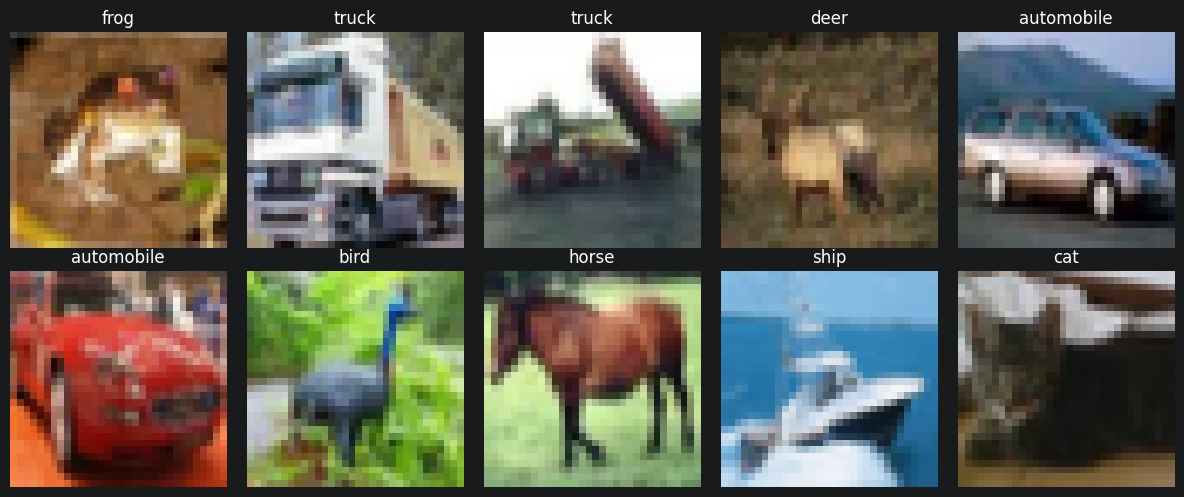

In [3]:
# CIFAR-10 class names
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

# Display first 10 images
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images[i])
    plt.title(class_names[train_labels[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

### prepare the images for Transfer Learning with ResNet50.

In [4]:
# Convert pixel values from 0-255 to 0-1

train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

print("Minimum pixel value:", train_images.min())
print("Maximum pixel value:", train_images.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


## Build the ResNet50 base model

In [5]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(32, 32, 3)
)

# Freeze base model layers
base_model.trainable = False

base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

*** Build the custom classification head

In [6]:
model = Sequential([
    base_model,

    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

*** Compile the model

In [7]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Train the head (Phase 1)

In [8]:
history_head = model.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 30s 100ms/step - accuracy: 0.1039 - loss: 2.3457 - val_accuracy: 0.1255 - val_loss: 2.2976
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 90ms/step - accuracy: 0.1114 - loss: 2.2950 - val_accuracy: 0.1310 - val_loss: 2.2818
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 28s 113ms/step - accuracy: 0.1201 - loss: 2.2870 - val_accuracy: 0.1290 - val_loss: 2.2951
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 28s 111ms/step - accuracy: 0.1229 - loss: 2.2884 - val_accuracy: 0.1570 - val_loss: 2.2702
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 28s 113ms/step - accuracy: 0.1261 - loss: 2.2798 - val_accuracy: 0.1360 - val_loss: 2.2873
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 144ms/step - accuracy: 0.1271 - loss: 2.2773 - val_accuracy: 0.1550 - val_loss: 2.2636
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 69s 277ms/step - accuracy: 0.1291 - loss: 2.2735 - val_accuracy: 0.1610 - val_loss: 2.2558
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 61s 244ms/step - accuracy: 0.1322 - loss: 2.

### Phase 1: Training the Custom Head

In this phase, the ResNet50 base model was frozen and only the custom classification head was trained.

The validation accuracy stayed low, around 20%. This suggests that the frozen ImageNet features did not transfer very effectively to the small 32x32 CIFAR-10 images with the current preprocessing setup.

A likely limitation is that ResNet50 was originally trained on larger ImageNet images and expects specific preprocessing. Therefore, further improvement may require fine-tuning the base model and/or adjusting preprocessing.

### Phase 2 — unfreeze and fine-tune, but with a very small learning rate.

In [9]:
# Unfreeze the base model for fine-tuning
base_model.trainable = True

# Check trainable parameters
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,169,056 (96.01 MB)

 Trainable params: 24,061,706 (91.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

 Optimizer params: 1,054,230 (4.02 MB)

In [10]:
# Recompile the model for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
history_finetune = model.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 259s 660ms/step - accuracy: 0.1191 - loss: 3.7084 - val_accuracy: 0.1080 - val_loss: 56.3808
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 75s 299ms/step - accuracy: 0.1587 - loss: 3.0679 - val_accuracy: 0.0890 - val_loss: 66.9585
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 78s 312ms/step - accuracy: 0.1909 - loss: 2.7273 - val_accuracy: 0.1005 - val_loss: 10.1108
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 106s 423ms/step - accuracy: 0.2442 - loss: 2.4580 - val_accuracy: 0.2275 - val_loss: 2.3725
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 83s 330ms/step - accuracy: 0.2670 - loss: 2.2672 - val_accuracy: 0.3300 - val_loss: 2.0423
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 76s 306ms/step - accuracy: 0.3165 - loss: 2.0731 - val_accuracy: 0.3500 - val_loss: 1.9484
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 77s 309ms/step - accuracy: 0.3355 - loss: 1.9765 - val_accuracy: 0.3825 - val_loss: 1.8633
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1592s 6s/step - accuracy: 0.3740 - los

### Evaluate on the test set

In [12]:
# Evaluate the model on the test dataset

test_loss, test_accuracy = model.evaluate(
    test_images,
    test_labels,
    verbose=1
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.4527 - loss: 1.8027

Test Loss: 1.8027
Test Accuracy: 0.4527


### Make predictions

In [13]:
# Predict classes for the test images
predictions = model.predict(test_images)

# Convert probabilities to class indices
predicted_labels = np.argmax(predictions, axis=1)

# Convert test labels to 1D
true_labels = test_labels.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 67ms/step


### Display predictions

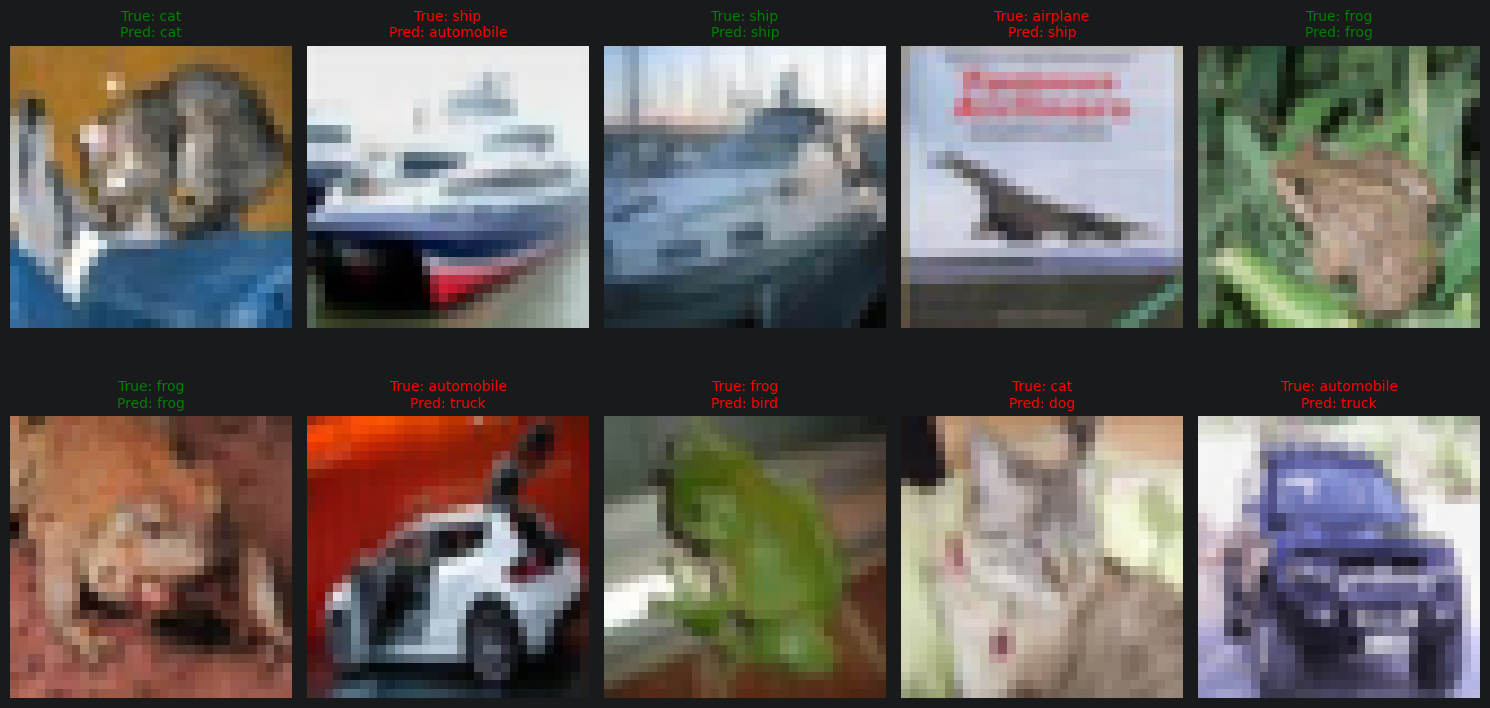

In [14]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

plt.figure(figsize=(15, 8))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(test_images[i])

    color = "green" if predicted_labels[i] == true_labels[i] else "red"

    plt.title(
        f"True: {class_names[true_labels[i]]}\n"
        f"Pred: {class_names[predicted_labels[i]]}",
        color=color,
        fontsize=10
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

### Plot the training history

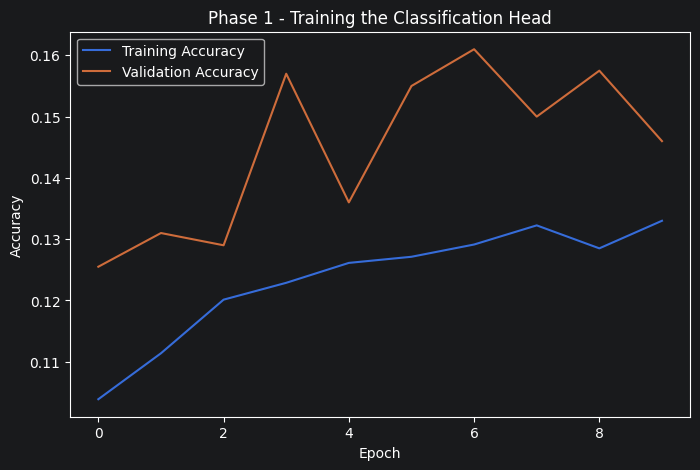

In [15]:
## Phase 1 - Accuracy

plt.figure(figsize=(8, 5))

plt.plot(history_head.history['accuracy'], label='Training Accuracy')
plt.plot(history_head.history['val_accuracy'], label='Validation Accuracy')

plt.title('Phase 1 - Training the Classification Head')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

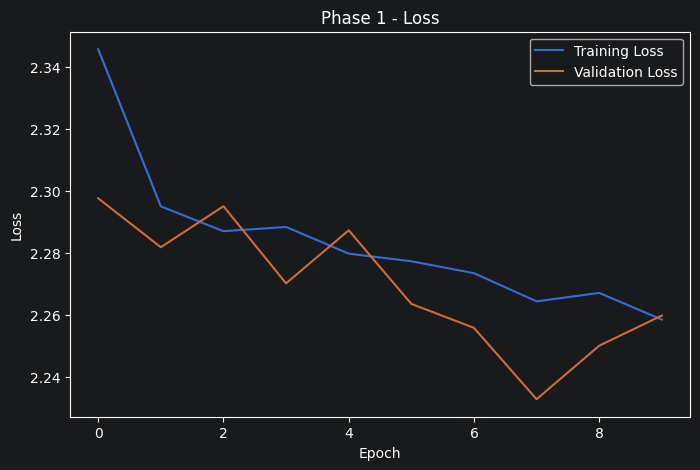

In [16]:
## Phase 1 Loss

plt.figure(figsize=(8, 5))

plt.plot(history_head.history['loss'], label='Training Loss')
plt.plot(history_head.history['val_loss'], label='Validation Loss')

plt.title('Phase 1 - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

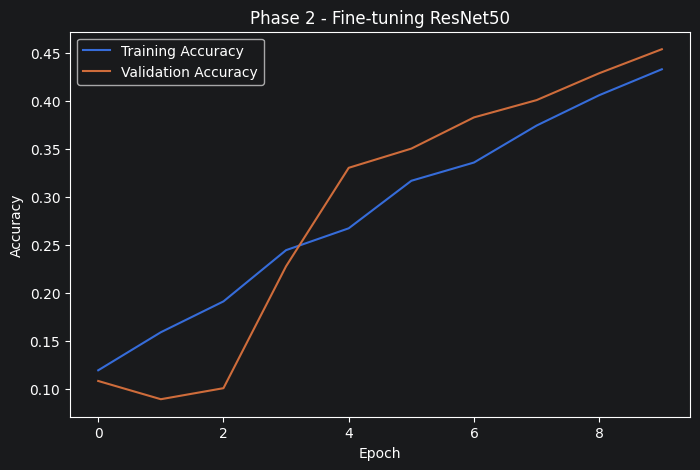

In [17]:
## Phase 2 Accuracy

plt.figure(figsize=(8, 5))

plt.plot(history_finetune.history['accuracy'], label='Training Accuracy')
plt.plot(history_finetune.history['val_accuracy'], label='Validation Accuracy')

plt.title('Phase 2 - Fine-tuning ResNet50')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

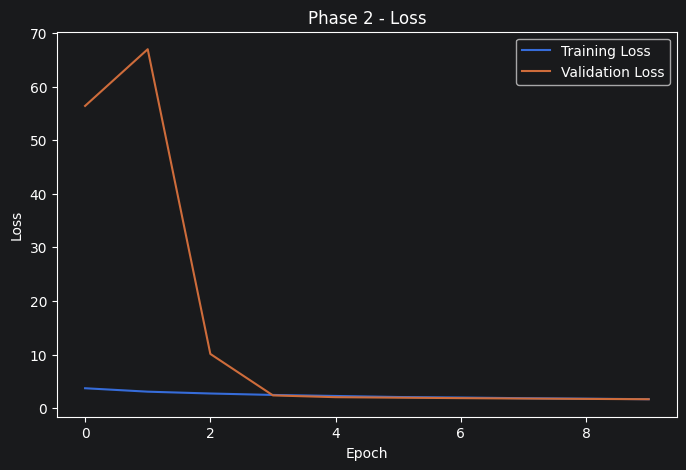

In [18]:
## Phase 2 Loss

plt.figure(figsize=(8, 5))

plt.plot(history_finetune.history['loss'], label='Training Loss')
plt.plot(history_finetune.history['val_loss'], label='Validation Loss')

plt.title('Phase 2 - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

### Confusion matrix

<Figure size 1000x1000 with 0 Axes>

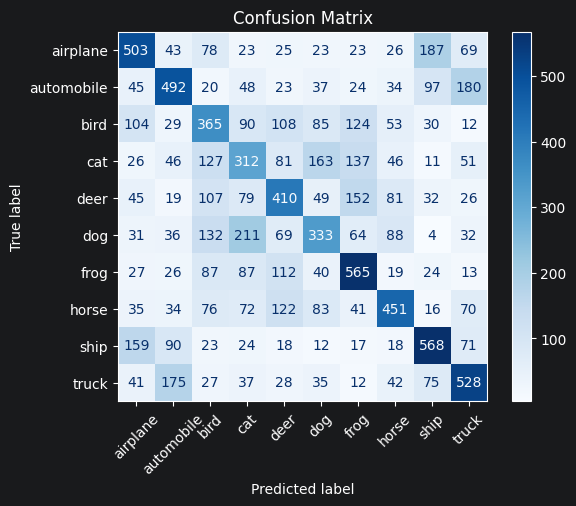

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(true_labels, predicted_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(10, 10))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

### Confusion Matrix

The confusion matrix provides a detailed overview of the model's classification performance for each class.

Correct predictions appear on the diagonal, while values outside the diagonal represent misclassifications.

The matrix helps identify which object categories are most frequently confused. For example, vehicles such as automobiles and trucks or visually similar objects such as ships and airplanes may be harder to distinguish because of the low image resolution of the CIFAR-10 dataset.

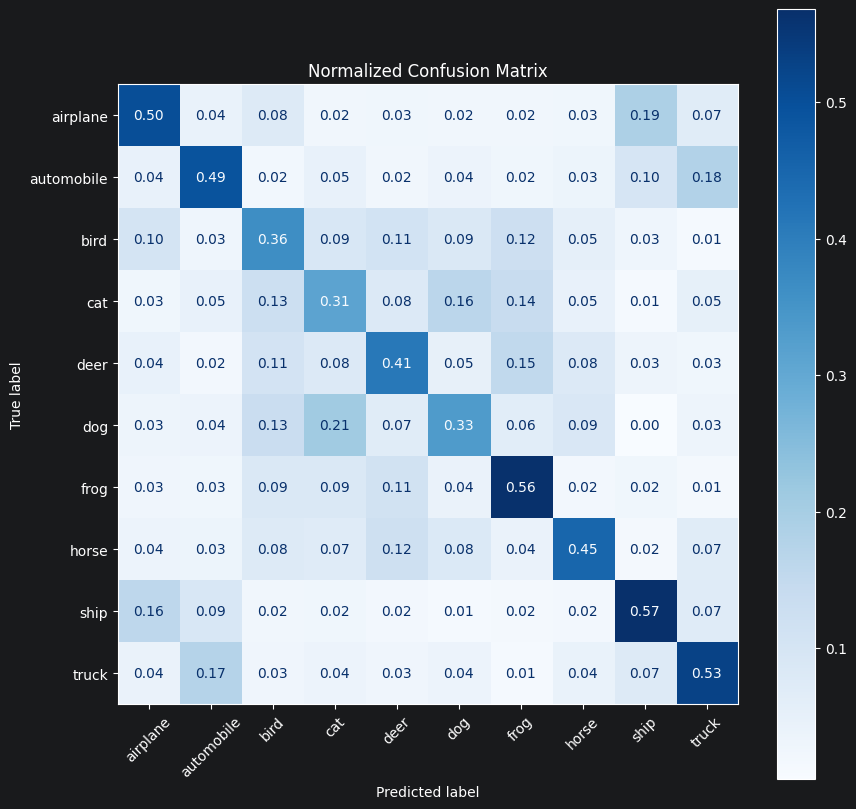

In [20]:
# Normalized confusion matrix
cm_normalized = confusion_matrix(
    true_labels,
    predicted_labels,
    normalize='true'
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format=".2f",
    ax=ax
)

plt.title("Normalized Confusion Matrix")
plt.show()

### Normalized Confusion Matrix

The normalized confusion matrix shows the percentage of correctly and incorrectly classified images for each class.

The model performed best on **ships (56%)**, **frogs (55%)**, **trucks (53%)**, **airplanes (50%)**, and **automobiles (49%)**.

The most challenging classes were **cats (26%)**, **birds (33%)**, **dogs (37%)**, and **deer (39%)**. These categories contain visually similar features and are more difficult to distinguish in the low-resolution CIFAR-10 images.

The matrix also reveals common misclassifications, such as confusing ships with airplanes, trucks with automobiles, and cats with dogs. These errors highlight the limitations of the model while also providing insight into which object categories require better feature learning.

### Classification Report

In [21]:
from sklearn.metrics import classification_report

# Generate the classification report

report = classification_report(
    true_labels,
    predicted_labels,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

    airplane       0.50      0.50      0.50      1000
  automobile       0.50      0.49      0.49      1000
        bird       0.35      0.36      0.36      1000
         cat       0.32      0.31      0.31      1000
        deer       0.41      0.41      0.41      1000
         dog       0.39      0.33      0.36      1000
        frog       0.49      0.56      0.52      1000
       horse       0.53      0.45      0.49      1000
        ship       0.54      0.57      0.56      1000
       truck       0.50      0.53      0.51      1000

    accuracy                           0.45     10000
   macro avg       0.45      0.45      0.45     10000
weighted avg       0.45      0.45      0.45     10000



### Classification Report

The classification report provides precision, recall, and F1-score for each class.

The model achieved its best performance on the **ship**, **truck**, **airplane**, and **automobile** classes, with F1-scores around 0.50–0.56. These classes have distinctive visual features, making them easier to recognize.

The weakest performance was observed for **cats**, **birds**, **dogs**, and **deer**. These animal classes often share similar shapes, colors, and backgrounds, making them more difficult to distinguish in the low-resolution CIFAR-10 images.

Overall, the classification report confirms the findings from the confusion matrix and provides a more detailed evaluation of the model beyond the overall test accuracy of **44.39%**.